# Mini 2D Flow Matching model

This notebook trains and evaluates a simple 2D FM model with CondOT (i.e., linear) scheduler.

Dataset: 2D checkerboard
Model (velocity): MLP

## Imports and init device

In [1]:
import time
import torch

from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt

from matplotlib import cm


# To avoide meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [3]:
torch.manual_seed(42)

## Dataset

In [4]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)

    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

## Model

In [5]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

## Train Velocity Flow Matching model

In [6]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000 
hidden_dim = 512

# velocity field model init
vf = MLP(input_dim=2, time_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf.parameters(), lr=lr) 

# train
start_time = time.time()
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    x_1 = inf_train_gen(batch_size=batch_size, device=device) # sample data
    x_0 = torch.randn_like(x_1).to(device)

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow( vf(path_sample.x_t,path_sample.t) - path_sample.dx_t, 2).mean() 

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item()))
        start_time = time.time()

| iter   2000 |  4.19 ms/step | loss    3.772 
| iter   4000 |  3.37 ms/step | loss    3.684 
| iter   6000 |  3.14 ms/step | loss    3.780 
| iter   8000 |  2.89 ms/step | loss    3.729 
| iter  10000 |  3.36 ms/step | loss    3.705 
| iter  12000 |  3.68 ms/step | loss    3.661 
| iter  14000 |  3.38 ms/step | loss    3.625 
| iter  16000 |  3.40 ms/step | loss    3.837 
| iter  18000 |  3.37 ms/step | loss    3.796 
| iter  20000 |  3.37 ms/step | loss    3.872 


#### Sample from trained model

In [7]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.model(x, t)

wrapped_vf = WrappedModel(vf)

In [8]:
# step size for ode solver
step_size = 0.05

norm = cm.colors.Normalize(vmax=50, vmin=0)

batch_size = 50000  # batch size
eps_time = 1e-2
T = torch.linspace(0,1,10)  # sample times
T = T.to(device=device)

def sample(
    batch_size=batch_size,
    device=device,
    wrapped_vf=wrapped_vf,
    T=T,
    step_size=step_size, 
    ):
    x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
    solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class
    sol = solver.sample(time_grid=T, x_init=x_init, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model
    return sol

sol = sample(batch_size=batch_size, device=device, wrapped_vf=wrapped_vf, T=T, step_size=step_size)

### Visualize the path

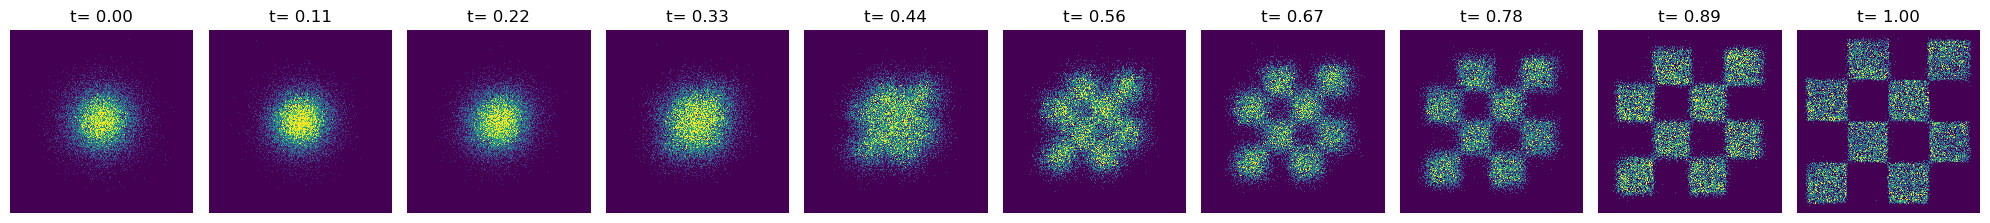

In [9]:
def plot_trajectory(sol, T):
    sol = sol.cpu().numpy()
    T = T.cpu()

    fig, axs = plt.subplots(1, 10,figsize=(20,20))

    for i in range(10):
        H= axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-5,5), (-5,5)))
        
        cmin = 0.0
        cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
        
        norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
        
        _ = axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-5,5), (-5,5)), norm=norm)
        
        axs[i].set_aspect('equal')
        axs[i].axis('off')
        axs[i].set_title('t= %.2f' % (T[i]))
        
    plt.tight_layout()
    plt.show()

plot_trajectory(sol, T)

### Visualize Target vs. Prediction

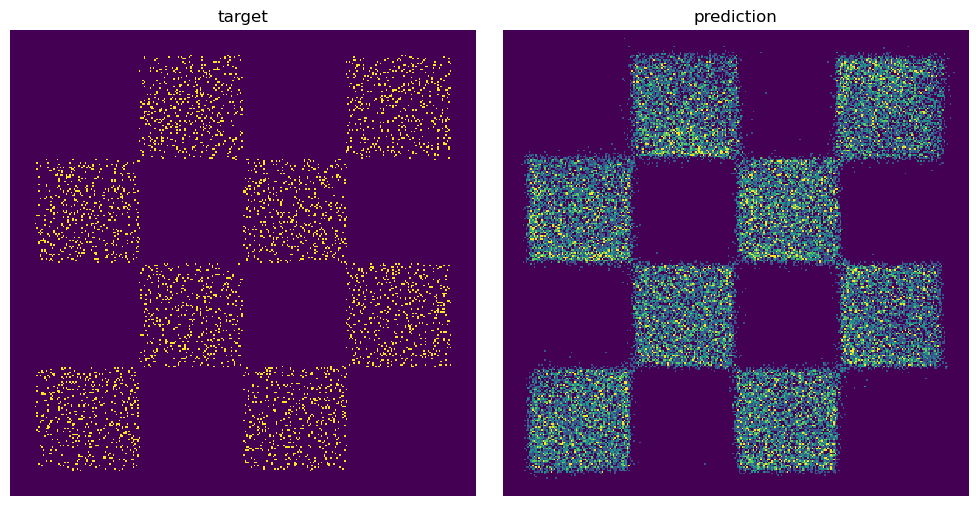

In [10]:
batch_size = 4096

def plot_pred_targ(sol):
    sol = sol.cpu().numpy()
    targ = inf_train_gen(batch_size=batch_size, device="cpu").numpy()
    targ_sol = {"target": targ, "prediction": sol[-1,:,:]}
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    for i, v in enumerate(["target", "prediction"]):
        H= axs[i].hist2d(targ_sol[v][:,0], targ_sol[v][:,1], 300, range=((-5,5), (-5,5)))

        cmin = 0.0
        cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
        
        norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

        _ = axs[i].hist2d(targ_sol[v][:,0], targ_sol[v][:,1], 300, range=((-5,5), (-5,5)), norm=norm)

        axs[i].set_aspect('equal')
        axs[i].axis('off')
        axs[i].set_title(v)
        
    plt.tight_layout()
    plt.show()

plot_pred_targ(sol=sol)

### Check Training

In [11]:
def check_training():
    T = torch.linspace(0,1,10)  # sample times
    T = T.to(device=device)
    wrapped_vf = WrappedModel(vf)
    sol = sample(batch_size=batch_size, device=device, wrapped_vf=wrapped_vf, T=T, step_size=step_size)
    plot_trajectory(sol, T)


| step  100 |  3.41 ms/step | loss 4.0851


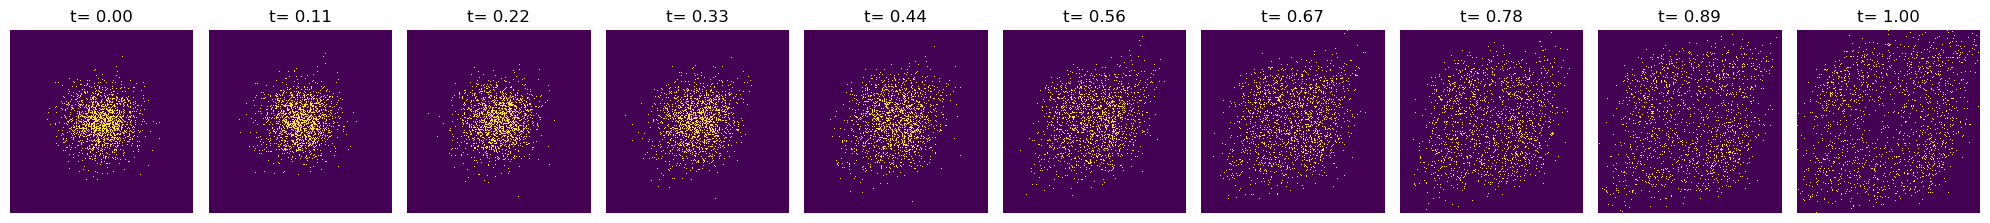

| step  200 |  3.35 ms/step | loss 3.9368


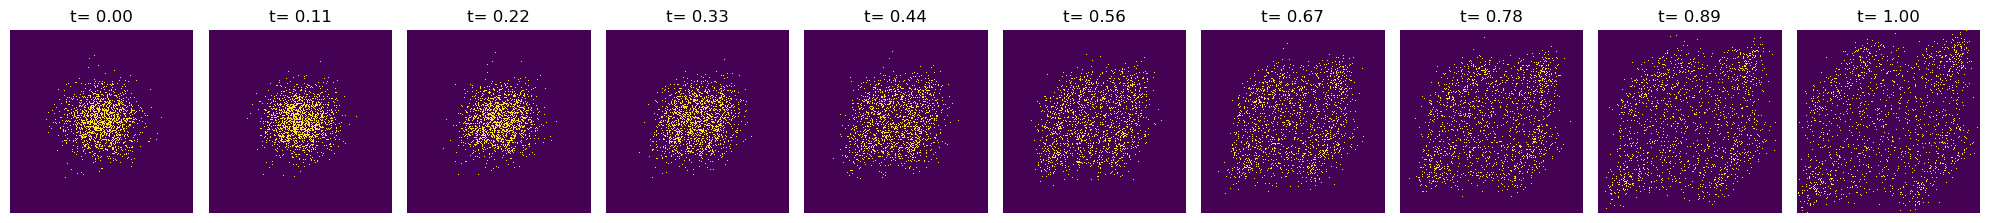

| step  300 |  2.91 ms/step | loss 3.9062


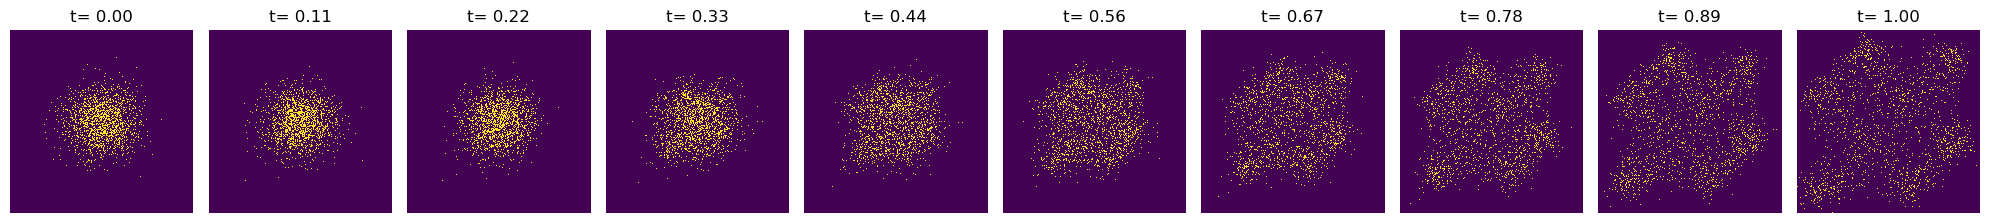

| step  400 |  3.40 ms/step | loss 3.7483


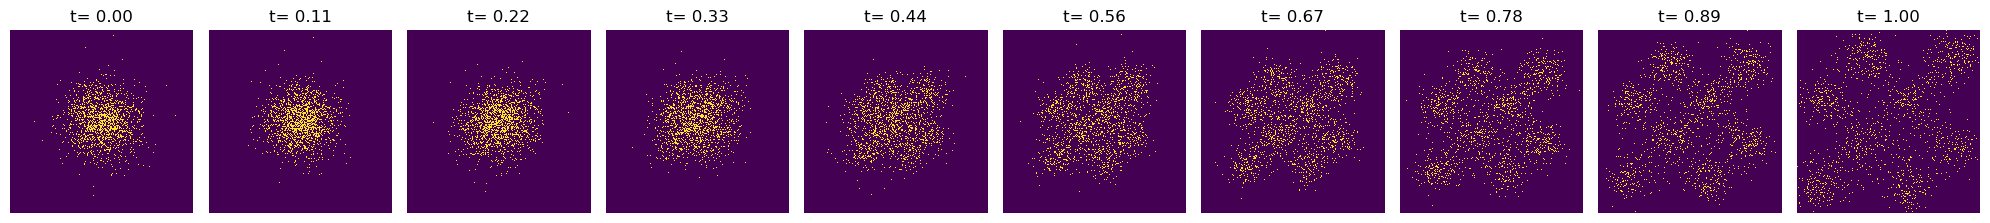

| step  500 |  2.91 ms/step | loss 3.8065


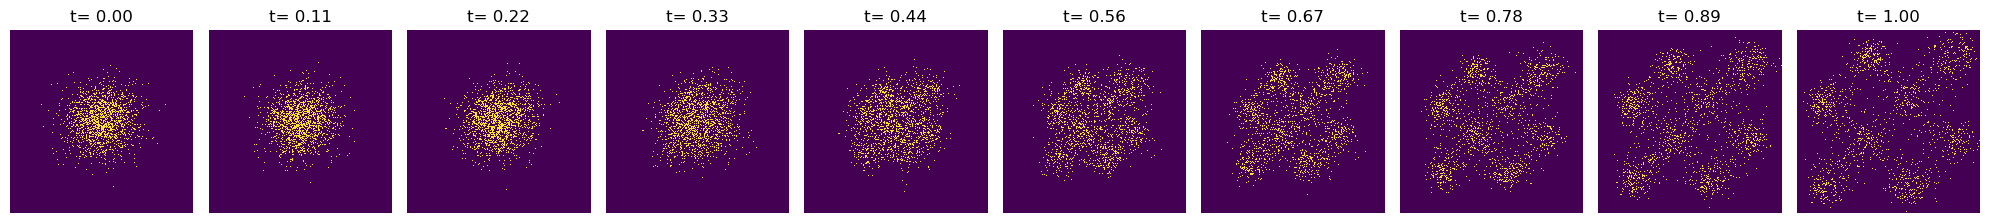

| step  600 |  3.39 ms/step | loss 3.9013


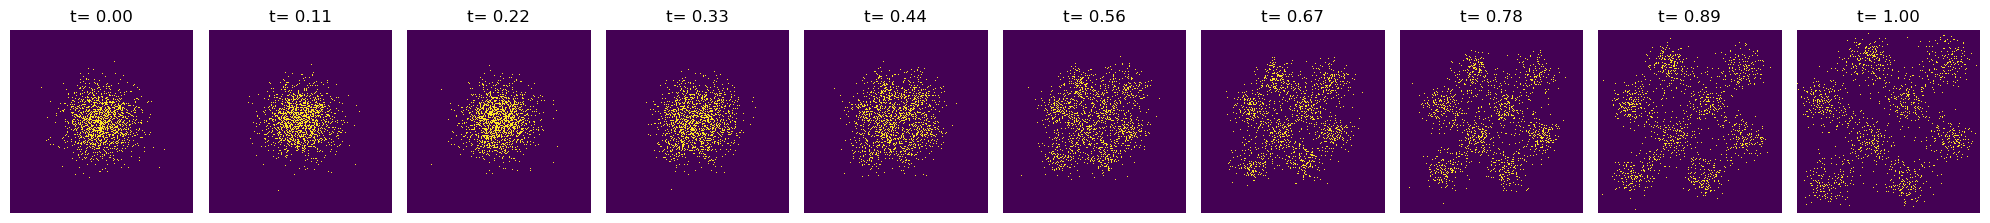

| step  700 |  3.40 ms/step | loss 3.8220


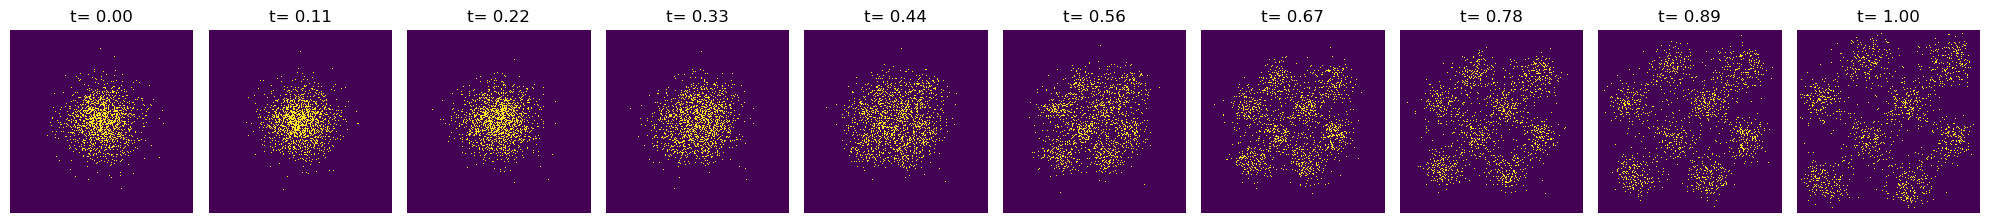

| step  800 |  2.90 ms/step | loss 3.8742


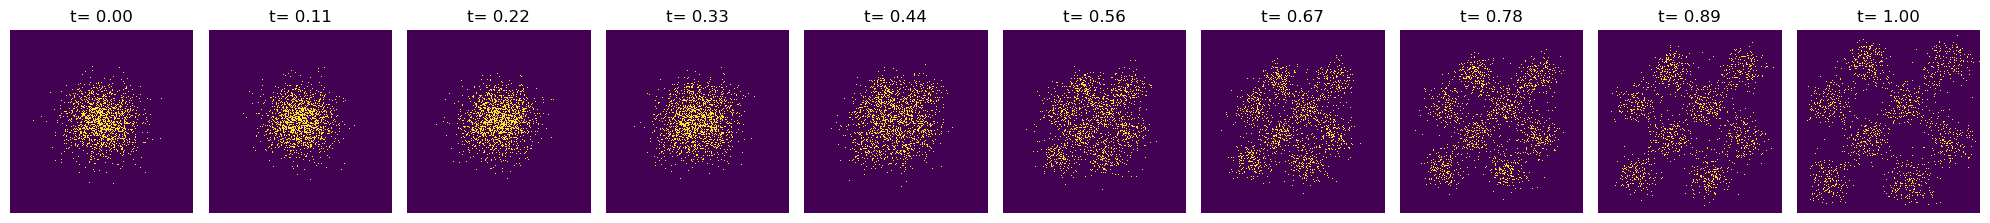

| step  900 |  3.40 ms/step | loss 3.8065


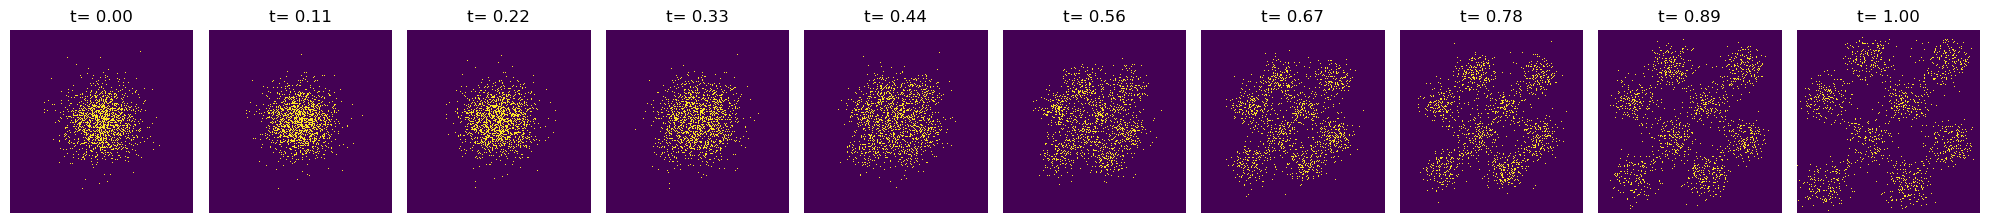

| step 1000 |  2.91 ms/step | loss 3.7678


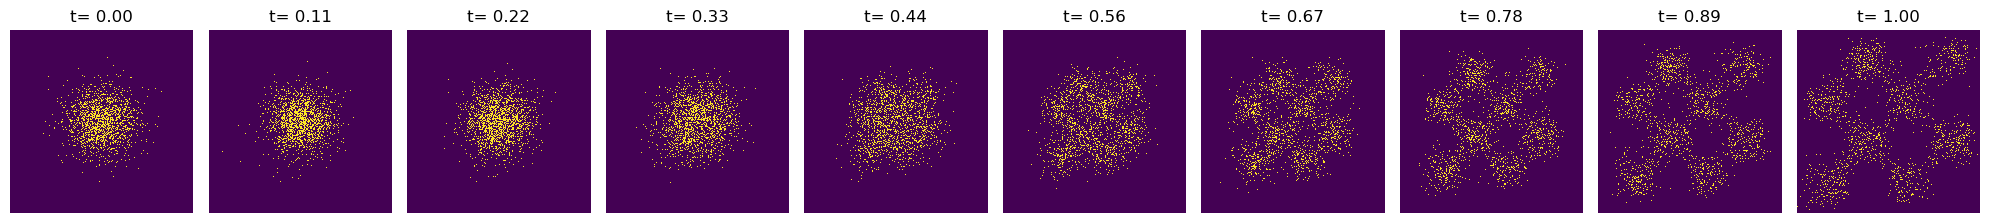

| step 2000 |  1.70 ms/step | loss 3.9000


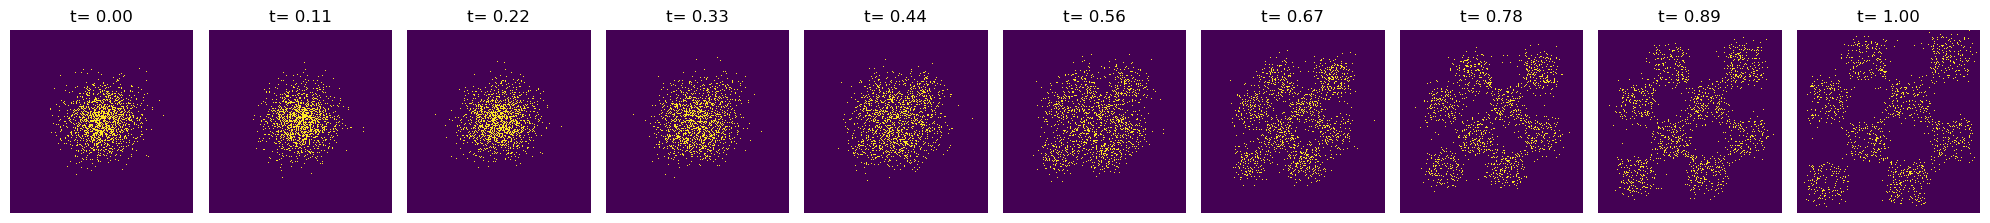

| step 4000 |  3.39 ms/step | loss 3.6035


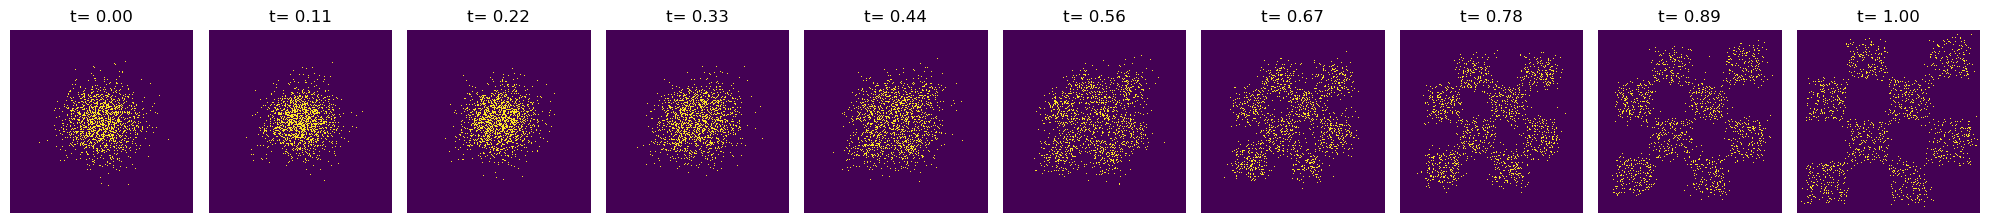

| step 6000 |  3.38 ms/step | loss 3.8347


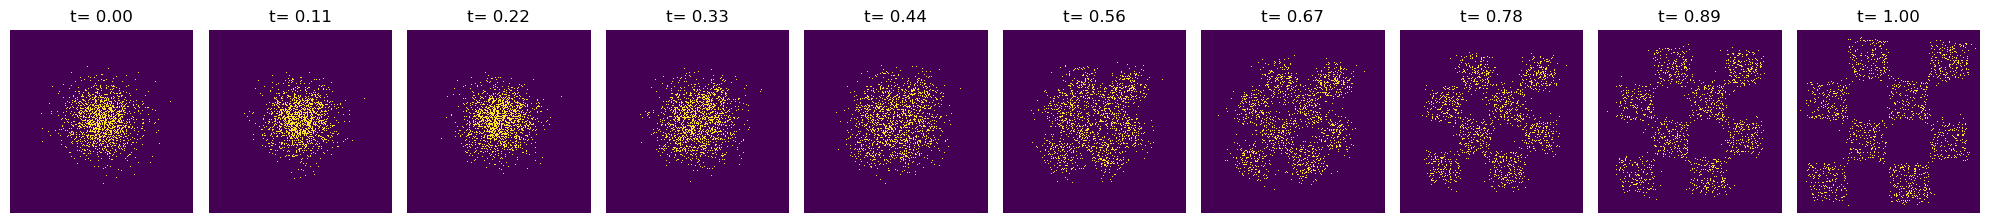

| step 8000 |  3.39 ms/step | loss 3.9599


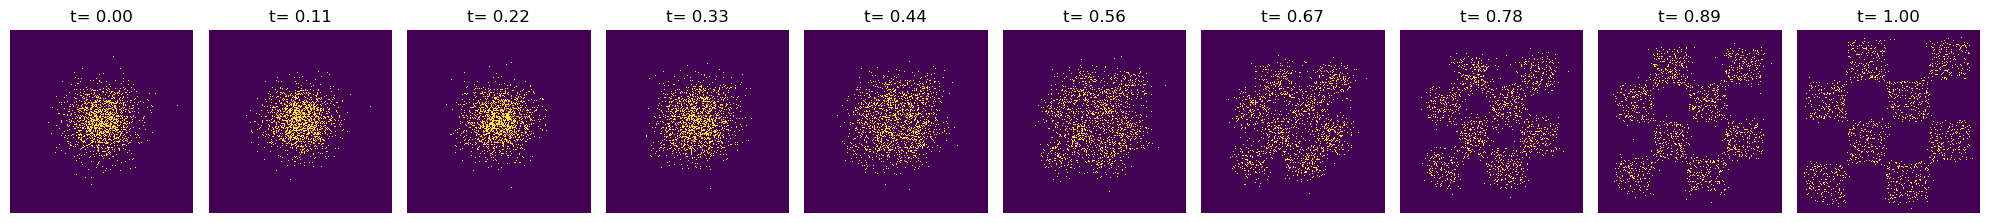

| step 10000 |  3.39 ms/step | loss 3.6647


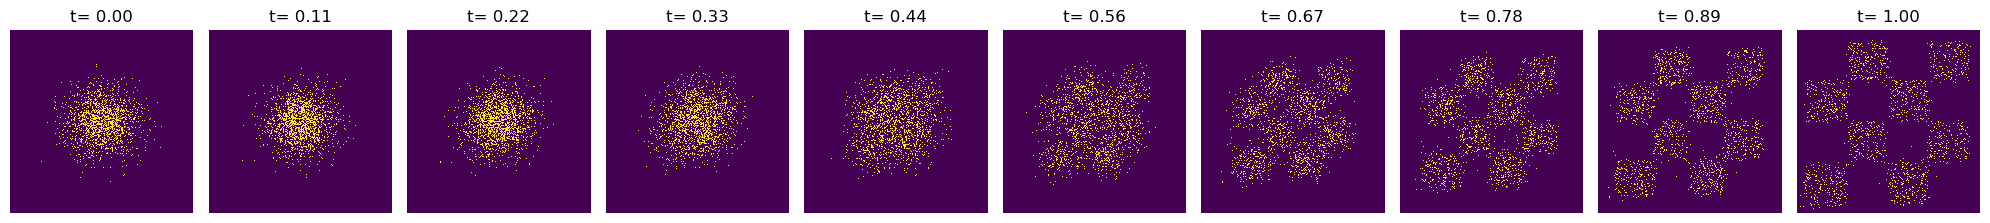

| step 12000 |  3.40 ms/step | loss 3.7236


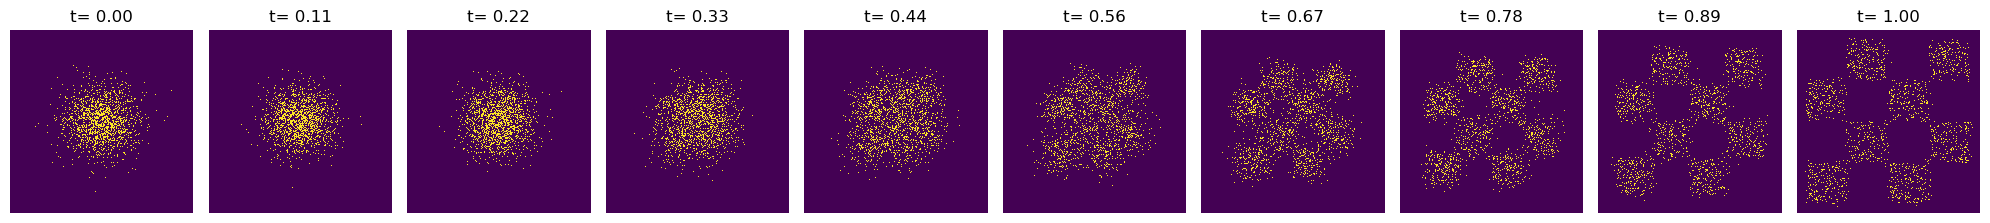

| step 14000 |  3.39 ms/step | loss 3.8024


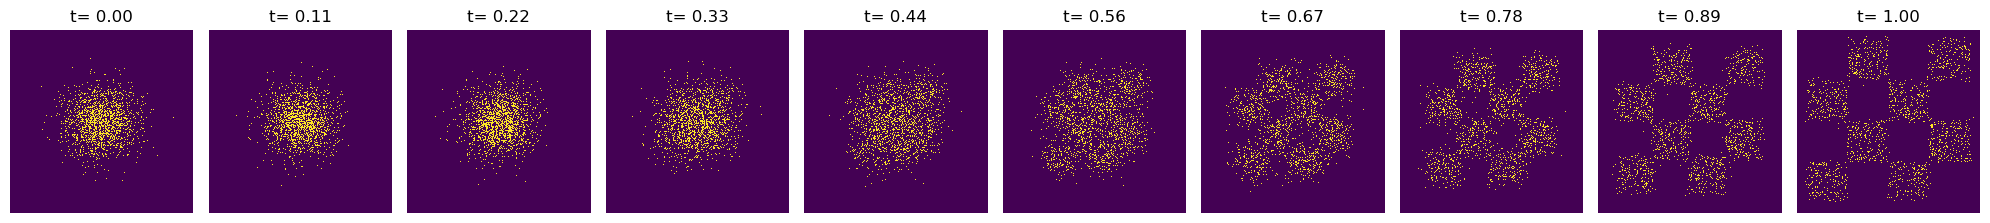

| step 16000 |  3.39 ms/step | loss 3.6679


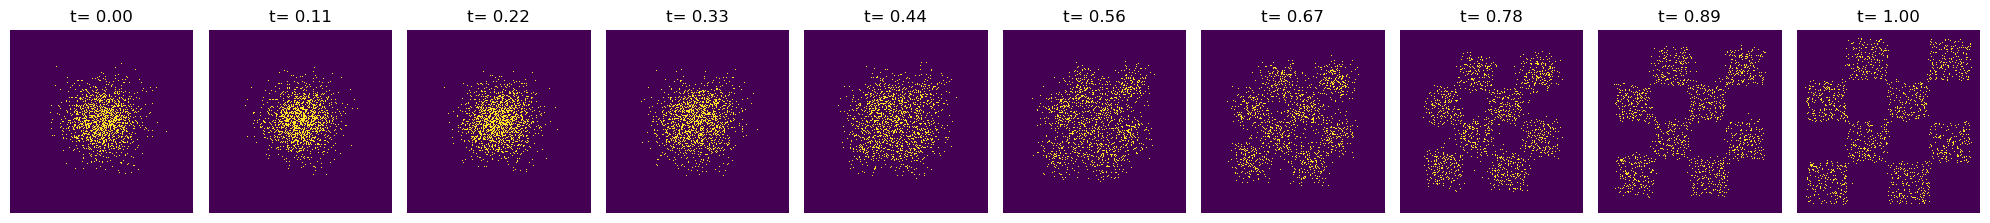

| step 18000 |  3.38 ms/step | loss 3.8661


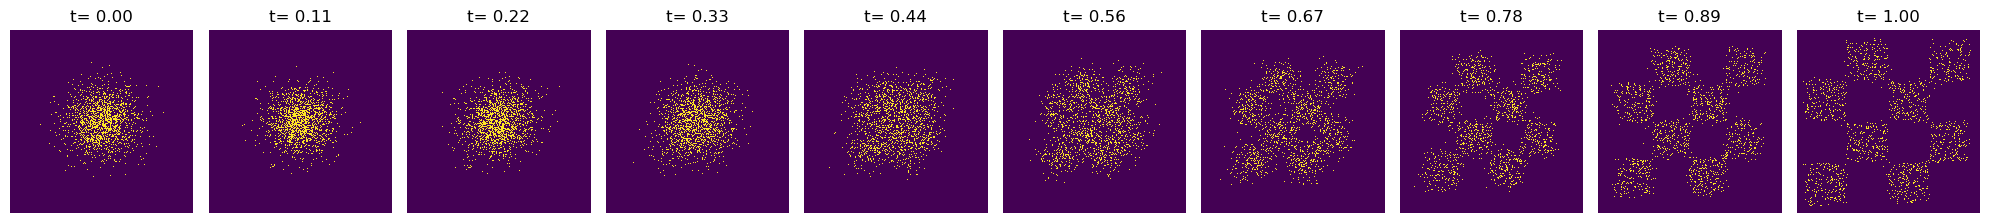

| step 20000 |  3.43 ms/step | loss 3.8486


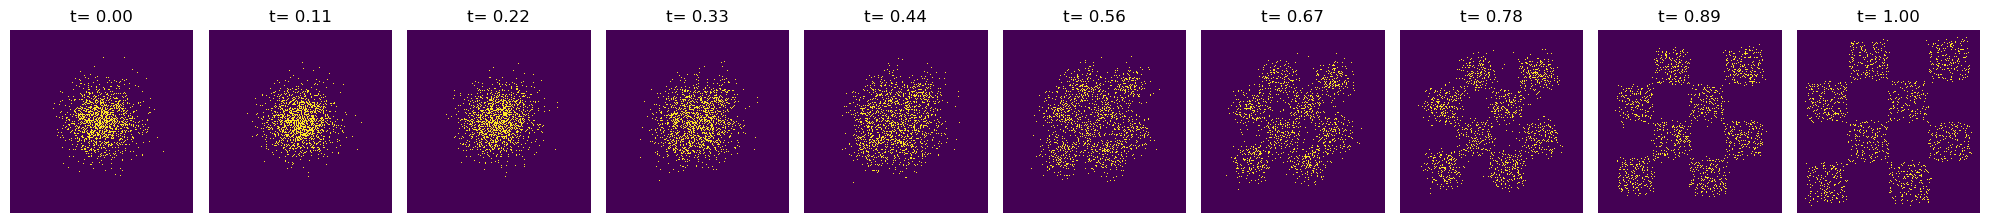

In [13]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
initial_print_every = 100
switch_step = 1000
later_print_every = 4000 
hidden_dim = 512

# velocity field model init
vf = MLP(input_dim=2, time_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf.parameters(), lr=lr) 

# train
start_time = time.time()
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    x_1 = inf_train_gen(batch_size=batch_size, device=device) # sample data
    x_0 = torch.randn_like(x_1).to(device)

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow( vf(path_sample.x_t,path_sample.t) - path_sample.dx_t, 2).mean() 

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if i < switch_step:
        if (i+1) % initial_print_every == 0:
            elapsed = time.time() - start_time
            print(f"| step {i+1:4d} | {elapsed*1000/initial_print_every:5.2f} ms/step | loss {loss.item():.4f}")
            check_training()
            start_time = time.time()
    else:
        if (i+1) % later_print_every == 0:
            elapsed = time.time() - start_time
            print(f"| step {i+1:4d} | {elapsed*1000/later_print_every:5.2f} ms/step | loss {loss.item():.4f}")
            check_training()
            start_time = time.time()